In [1]:
from inspectre import Inspectre, ray_sampling
import numpy as np
from scipy import integrate as it
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
from scipy.interpolate import CubicSpline
import tqdm
from copy import deepcopy
from scipy.integrate import quad

In [2]:
p = 10.0
e = 0.3
a = 0.5
x = 1

m = 2
n = 2

mass = 1.0
err = 1e-15
orbit="equatorial"

insp = Inspectre(
    spin=a,
    semilatus_rect=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    orbit=orbit
)

insp_adapt = Inspectre(
    spin=a,
    semilatus_rect=p,
    eccentricity=e,
    x=x,
    mass=mass,
    err=err,
    orbit=orbit
)

radial_period = 2. * np.pi / insp.omega_r

r_min = p / (1.0 + e)
r_max = p / (1.0 - e)

r_plus = mass * ( 1. + np.sqrt(1.-(a/mass)**2))
r_minus = mass * (1. - np.sqrt(1.-(a/mass)**2))

def delta(r):
    return r**2 - 2.0*mass*r + a**2

def sigma(r, theta):
    return r**2 + a**2 * np.cos(theta)**2

def phi_minus_phi(r):
    return a / (r_plus - r_minus) * np.log( (r - r_plus) / (r - r_minus) )

datagrid = np.load('effsource_data.npy')
datagrid = datagrid[(datagrid.T[0] > r_min-1)&(datagrid.T[0] < r_max+5)&(np.abs(datagrid.T[1] -np.pi/2) < 0.01)]

In [3]:
def distance_2d(r_field, theta_field, r_p):    
    rSqr = r_p * r_p + r_field * r_field
    angDist = 2.0 * r_field * r_p * np.sin(theta_field)
    return np.sqrt(rSqr - angDist)

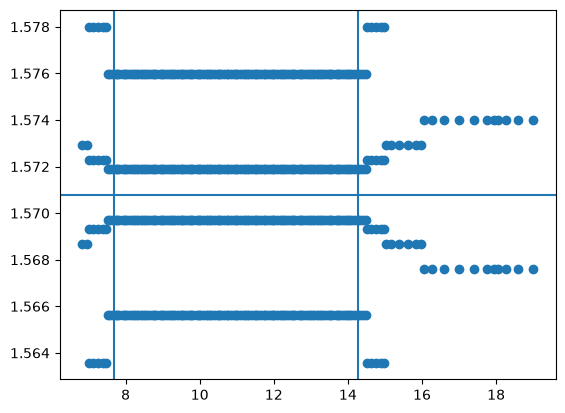

In [4]:
plt.scatter(datagrid.T[0],datagrid.T[1])
plt.axhline(y=np.pi/2)
plt.axvline(x=r_min)
plt.axvline(x=r_max)
# plt.xscale('log')
plt.show()

In [36]:
dist_list = np.array([[r, t, distance_2d(r, t, 10), reES, imES] for r,t,reES,imES in datagrid])
r_field, theta_field, _, reES, imES = dist_list[np.argmax(dist_list.T[2])]
# print(r_field, np.cos(theta_field), reES, imES)
r_field = 10.6293
theta_field = np.arccos(0.00417747)

In [37]:
theta_field

np.float64(1.5666188446444518)

In [7]:
def spectre_rescale(r_field, theta_field, eff_source):
    coeff = r_field / (2. * np.pi * np.sin(theta_field)**abs(m))
    coeff *= sigma(r_field,theta_field) / (r_field**2 + a**2)
    return coeff*np.exp(-1j*m*phi_minus_phi(r_field))*eff_source

In [9]:
# insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**14)
# src_m = insp.source_mmode_along_trajectory(m, r_field, theta_field)
# f = np.fft.fftshift(np.fft.fftfreq(len(src_m.T[1])))
# fd_dat = np.fft.fftshift(np.fft.fft(src_m.T[1]+1j*src_m.T[2])) * src_m.T[0][-1] / len(src_m.T[0])
# plt.semilogy(f,np.abs(fd_dat))
# plt.axvline(x=(m*insp.omega_phi + n * insp.omega_r)/(2.0*np.pi))
# plt.show()

In [42]:
insp.generate_equatorial_trajectory(num_periods=1, num_pts=500)
traj_sparse = deepcopy(insp.trajectory)
src_mn_sparse = insp.source_mn_integrand_along_trajectory(m, n, r_field, theta_field)

# insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**14)
# traj_full = deepcopy(insp.trajectory)
# src_mn_full = insp.source_mn_integrand_along_trajectory(m, n, r_field, theta_field)

# insp_adapt.generate_equatorial_trajectory(num_periods=1, num_pts=2**14)

In [43]:
# spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
spdata_re_sparse = CubicSpline(src_mn_sparse.T[0], src_mn_sparse.T[1], bc_type='periodic')
spdata_im_sparse = CubicSpline(src_mn_sparse.T[0], src_mn_sparse.T[2], bc_type='periodic')

sp_integrate_sparse = (
    spdata_re_sparse.integrate(0.0, src_mn_sparse.T[0][-1]) +
    1j*spdata_im_sparse.integrate(0.0, src_mn_sparse.T[0][-1])) / radial_period
spectre_sp = spectre_rescale(r_field, theta_field, sp_integrate_sparse)

# print(reES,spectre_sp.real, imES, spectre_sp.imag)
print(np.real(spectre_sp), np.imag(spectre_sp))

0.00026528441358933744 2.772463208946329e-05


In [40]:
# spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
spdata_re_full = CubicSpline(src_mn_full.T[0], src_mn_full.T[1], bc_type='periodic').integrate(0.0, src_mn_full.T[0][-1]) / radial_period
spdata_im_full = CubicSpline(src_mn_full.T[0], src_mn_full.T[2], bc_type='periodic').integrate(0.0, src_mn_full.T[0][-1]) / radial_period
sp_integrate_full = (spdata_re_full + 1j*spdata_im_full)
spectre_sp_full = spectre_rescale(r_field, theta_field, sp_integrate_full)

# print(reES,spectre_sp_full.real, imES,  spectre_sp_full.imag)
print(spectre_sp_full.real, spectre_sp_full.imag)

0.00019363832469657233 2.023696467861854e-05


In [334]:
# t_full = traj_full['t']
# r_full = traj_full['r']
# ur_full = traj_full['ur']

# dist = distance_2d(r_field, theta_field, r_full)**2
# dist = 9. * (dist - np.min(dist)) / np.max(dist - np.min(dist))+1
# # dist /= np.max(dist)/2
# # dist += 1

# plt.plot(t_full,dist)
# # plt.plot(t_full,(1.0 - ur_full**2)**4)
# # plt.xlim(40,60)
# plt.show()

In [362]:
r_of_t = IUS(traj_full['t'], traj_full['r'])
ur_of_t = IUS(traj_full['t'], traj_full['ur'])
dist = distance_2d(r_field, theta_field, traj_full['r'])
dist_min = np.min(dist)
dist_max = np.max(dist)
print(dist_min, dist_max)

t_arr = []
t_tot = 0
dt = 0.1
# while t_tot <= radial_period:
#     t_arr.append(t_tot)
#     if distance_2d(r_field, theta_field, r_of_t(t_tot))/ r_field < 0.1:
#         dt = 0.5
#     elif distance_2d(r_field, theta_field, r_of_t(t_tot)) / r_field < 0.05:
#         dt = 0.1
#     else:
#         dt = 1.
#     t_tot += dt
while t_tot < radial_period:
    t_arr.append(t_tot)
    # dist = distance_2d(r_field, theta_field, r_of_t(t_tot))
    # t_tot += dt * (99. * (dist - dist_min) / dist_max + 1)
    # t_tot += dt * (1.-ur_of_t(t_tot)**2)
    dt_adapt = np.min([dt * (distance_2d(r_field, theta_field, r_of_t(t_tot)) / dist_min), 1])
    t_tot += dt_adapt

t_arr = np.array(t_arr)
t_arr = np.concatenate((t_arr[t_arr < radial_period],np.array([traj_full['t'][-1]])))
print(len(t_arr))

0.010830020160906638 4.303091749495645
327


In [363]:
insp_adapt.resample_trajectory(new_indep_array=t_arr)

In [364]:
# insp.generate_equatorial_trajectory(num_periods=1, num_pts=2**12)
src_mn_adapt = insp_adapt.source_mn_integrand_along_trajectory(m, n, r_field, theta_field)

In [365]:
np.trapezoid(
    src_mn_adapt.T[1] * np.gradient(src_mn_adapt.T[0]), 
    x = np.arange(len(src_mn_adapt.T[1]))
    )/radial_period

np.float64(0.00027663369669319595)

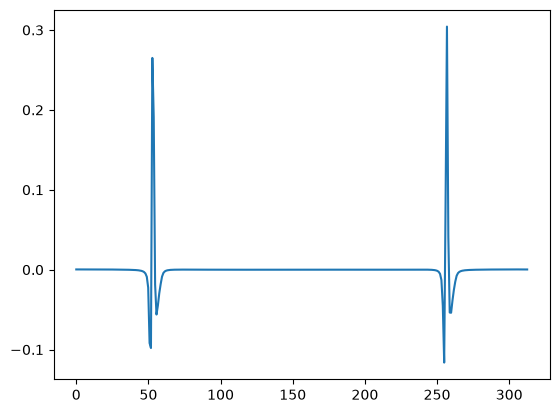

In [366]:
plt.plot(
    np.arange(len(src_mn_adapt.T[1]))*src_mn_adapt.T[0][-1]/len(src_mn_adapt.T[0]), 
    src_mn_adapt.T[1] * np.gradient(src_mn_adapt.T[0])
    )
plt.plot()
plt.show()

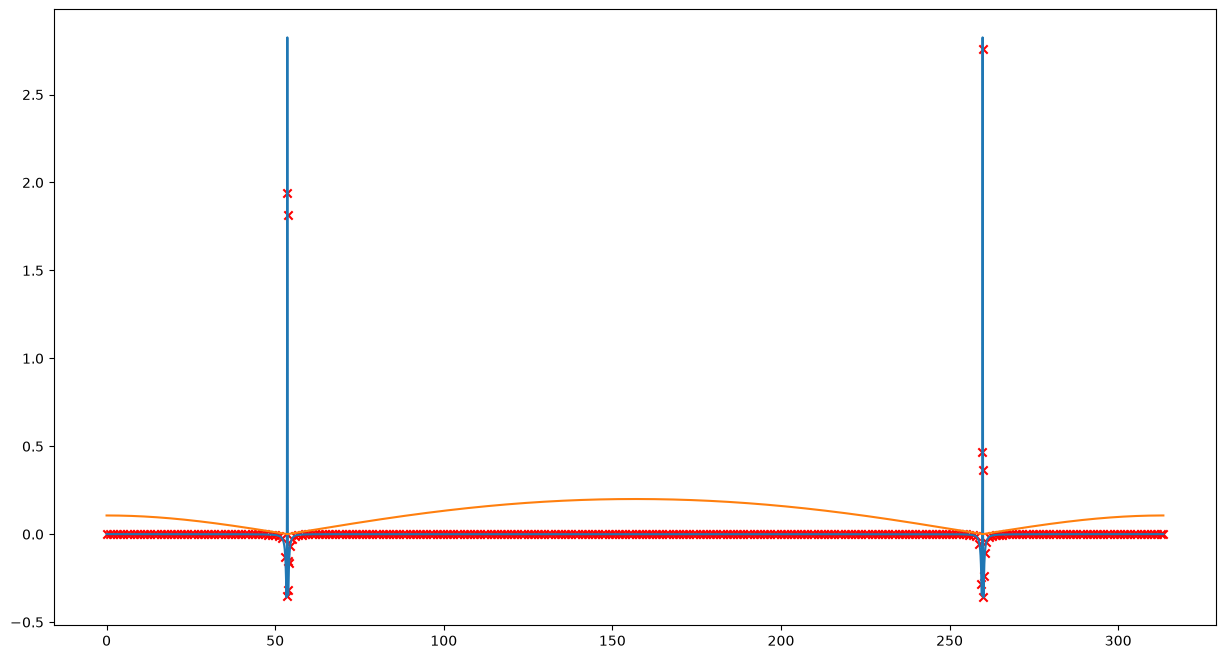

In [367]:
plt.figure(figsize=(15,8))
plt.plot(src_mn_full.T[0], src_mn_full.T[1])
# plt.plot(src_mn_full.T[0], (distance_2d(r_field, theta_field, traj_full['r'])/r_traj_min)**(1))
# plt.plot(src_mn_full.T[0], (1.-ur_of_t(src_mn_full.T[0])**2)**(8))
plt.scatter(src_mn_adapt.T[0], src_mn_adapt.T[1],marker='x', c='r')
plt.plot(traj_full['t'], dist/dist_max/5)
# plt.xlim(45,106)
# plt.ylim(-1,2)
plt.show()

In [368]:
# spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
spdata_re_sparse = CubicSpline(src_mn_sparse.T[0], src_mn_sparse.T[1], bc_type='periodic')
spdata_im_sparse = CubicSpline(src_mn_sparse.T[0], src_mn_sparse.T[2], bc_type='periodic')

sp_integrate_sparse = (spdata_re_sparse.integrate(0.0, src_mn_sparse.T[0][-1]) ) / radial_period
# sp_quad = (quad(spdata_re, 0., t_arr[-1]) + 1j*quad(spdata_im, 0., t_arr[-1]))/radial_period

sim_lam_sparse = it.simpson(src_mn_sparse.T[1], x=src_mn_sparse.T[0]) / radial_period
tra_lam_sparse = np.trapezoid(src_mn_sparse.T[1], x=src_mn_sparse.T[0]) / radial_period

# spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
spdata_re_adapt = CubicSpline(src_mn_adapt.T[0], src_mn_adapt.T[1], bc_type='periodic')
spdata_im_adapt = CubicSpline(src_mn_adapt.T[0], src_mn_adapt.T[2], bc_type='periodic')

sp_integrate_adapt = (spdata_re_adapt.integrate(0.0, src_mn_adapt.T[0][-1]) ) / radial_period
# sp_quad = (quad(spdata_re, 0., t_arr[-1]) + 1j*quad(spdata_im, 0., t_arr[-1]))/radial_period

sim_lam_adapt = it.simpson(src_mn_adapt.T[1], x=src_mn_adapt.T[0]) / radial_period
tra_lam_adapt = np.trapezoid(src_mn_adapt.T[1], x=src_mn_adapt.T[0]) / radial_period

# spdata = IUS(src_mn.T[0], src_mn.T[1], k=3).integral(0.0,src_mn.T[0][-1])
spdata_full = CubicSpline(src_mn_full.T[0], src_mn_full.T[1], bc_type='periodic').integrate(0.0, src_mn_full.T[0][-1]) / radial_period
sim_lam_full = it.simpson(src_mn_full.T[1], x=src_mn_full.T[0]) / radial_period
tra_lam_full = np.trapezoid(src_mn_full.T[1], x=src_mn_full.T[0]) / radial_period

print("spline\t", 1. - sp_integrate_sparse / spdata_full, 1. - sp_integrate_adapt / spdata_full)
print("simpsons", 1. - sim_lam_sparse / sim_lam_full, 1. - sim_lam_adapt / sim_lam_full)
print("trapz\t", 1. - tra_lam_sparse / tra_lam_full, 1. - tra_lam_adapt / tra_lam_full)

spline	 8.258024149280121 -4.909256097742884
simpsons 7.869776611169117 -0.4691792253410627
trapz	 8.260366042387856 -0.8112576611013638


num pts = 100
num pts = 500
num pts = 1200
num pts = 2400
num pts = 4800


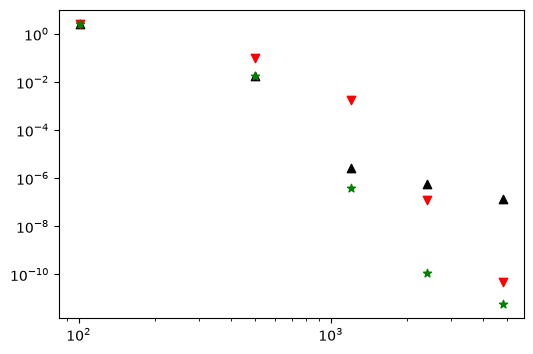

In [122]:
plt.figure(figsize=(6,4))
for i in [100, 500, 1200, 2400, 4800]:
    print(f"num pts = {i}")
    insp.generate_equatorial_trajectory(num_pts=i)
    src_mn = insp.source_mn_integrand_along_trajectory(m, n, r_field, theta_field)
    
    tres = src_mn.T[0]
    le = len(tres)
    trapz = np.trapezoid(src_mn.T[1], x=tres)
    simps = it.simpson(src_mn.T[1], x=tres)
    spdata_temp = CubicSpline(src_mn.T[0], src_mn.T[1], bc_type='periodic').integrate(0.0, src_mn.T[0][-1])
    trapz_rs = 1.0 - trapz / spdata
    simps_rs = 1.0 - simps / spdata
    spdata_rs = 1.0 - spdata_temp / spdata
    plt.scatter(le, abs(trapz_rs), marker='^', c='k')
    plt.scatter(le, abs(simps_rs), marker='v', c='r')
    plt.scatter(le, abs(spdata_rs), marker='*', c='g')

plt.yscale('log')
plt.xscale('log')
plt.show()